<h1>Real Estate Unit Price Prediction with Linear and Logistic Regression Models</h1>
<i>Original assignment: https://github.com/vesavvo/dkko/blob/211661c6bc980ee2ef852c2947cde88be65a45fc/assignments/Assignment_Linear_and_logistic_regression.md</i>

<h2>1. Business understanding</h2>
The pipeline uses data from https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set. The dataset contains real estate prices from a <i>Taiwanese</i> city called <i>New Taipei City</i> in <i>Sindian District</i>. The goal of this pipeline is to predict real estate prices of the area using the information from the dataset. <br/> <br/>

The goal of this pipeline is to predict real estate unit prices using the features in the dataset. Real estate unit prices will be predicted using a <b>Linear Regression model</b>. In addition, a <b>Logistic Regression model</b> will be used to classify whether a given unit price is above or below the mean price. 

By using this pipeline, we aim to help residents and real estate agents in Sindian District evaluate house prices when putting homes up for sale.

---

<h2>2. Data understanding</h2>

In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
df = fetch_ucirepo(id=477) 
df.data.original.head() #visualize the first five rows of the whole dataset

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


<center>Table 1. A first glance at the data. The dataset contains <b>six features</b>, presumably float values, and the target variable also appears to be a float.</center>

In [3]:
df.data.original.dtypes

No                                          int64
X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object

<center>Table 2. Data types verified: as expected, all features are floats except 'number of convenience stores', which is an integer.</center>

<br/>

The given dataset is well documented and the variables are descriptively named, which greatly helps us interpret the data.

---

<u>The values are indicated as such in the original documentation:</u>

<b>X1:</b> The transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.) <br/>
<b>X2:</b> The house age (unit: year)<br/>
<b>X3:</b> The distance to the nearest MRT station (unit: meter)<br/>
<b>X4:</b> The number of convenience stores in the living circle on foot (integer)<br/>
<b>X5:</b> The geographic coordinate, latitude. (unit: degree)<br/>
<b>X6:</b> The geographic coordinate, longitude. (unit: degree)<br/> 

<br/>

The output is as follow: <br/>
<b>Y:</b> house price of unit area (10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared)

---

In [4]:
print(df.data.original.isna().sum())
df.data.original.describe(include='all')

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


<center>Table 3 & 4. We made sure that there is no missing values and inconsistent data or data anomalies.</center>

<br/>
With <code>df.data.original.isna().sum()</code>, we get the exact count of missing values for each column. Thus, we confirmed that there are no missing values, as stated in the official documentation.

---

<h2>3. Data preparation</h2>

As we can see, there are magnitude differences in the given data, so the next step would be to normalize the values for efficient and accurate predictions. 

But before that, we have to separate the data into training and test data. We use the same split approach as was stated in the official ducumentation, so we are going to split the data 70/30, meaning 70% of data will be used for training the model and 30% for validation.

In [5]:
from sklearn.model_selection import train_test_split

X = df.data.features #dataset of only features
y = df.data.targets #dataset of only targets

#split features and targets to test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

The data has now been split into four subsets: feature and target sets for training and testing.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fits the scaler on training data (calculates mean and std) and transforms it
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# transforms test data using training parameters to prevent data leakage
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train_scaled.columns)

X_train_scaled.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-0.758469,-0.033580,0.861361,-0.390183,-0.474662,-1.353466
1,-1.646009,-0.404508,-0.462787,0.283028,-0.299716,0.249316
2,-0.758469,-0.335498,0.122613,-1.063394,0.673214,1.316976
3,0.423734,-1.198121,-0.395362,0.619633,0.266382,0.885135
4,0.129071,-0.326871,2.360495,-1.399999,-2.247226,-1.916989


<center>Table 5. A table of scaled variables</center>

<br/>

Now we have efficient magnitude on all the values and we are ready to start modeling.

---

<h2>4. Modeling</h2>

We will use linear regression model to predict housing prices per unit area. Before using multiple regression model, we can take a look on prediction model using single variable: house age.

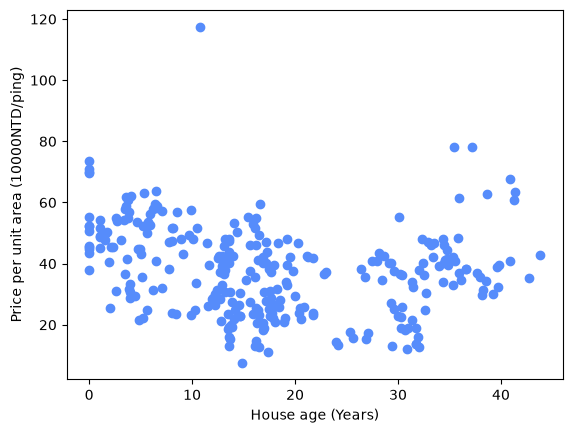

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X_train["X2 house age"], y_train)
plt.xlabel('House age (Years)')
plt.ylabel('Price per unit area (10000NTD/ping)')
plt.show()

Based on house age only, we can see a slight U-shape where the lowest price is on houses around 20-30 years old. This alone doesn't tell us the reason why, but could be explained by houses of that age aging out their essential infrastucture. Rising prices on older houses could then be explained by survivorship bias, where the houses had essential repairs done and those that did not were torn down.

Now, we will be build a regression model and train it. 

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled[["X2 house age"]], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-3.22]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['X2 house age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[38.13]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Finding trained values for model parameters:

In [9]:
b0 = model.intercept_
b1 = model.coef_[0]
print("Intercept: %.2f" % b0[0])
print("Coefficients:", ", ".join("%.4f" % x for x in b1))

Intercept: 38.13
Coefficients: -3.2178


Intercept: The expected value of the target variable when all predictors equal zero.
Coefficients: The specific effect of each independent variable on the outcome.

Finally, we can draw trendline corresponding to our regression model on top of our training data:

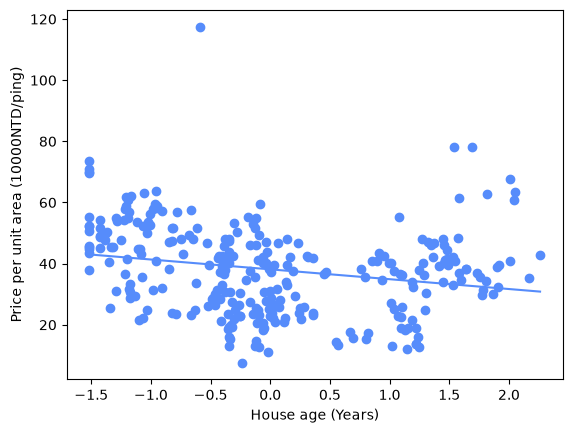

In [10]:
import numpy as np

xs = np.linspace(X_train_scaled[["X2 house age"]].min(), X_train_scaled[["X2 house age"]].max())
ys = b0 + b1 * xs
plt.plot(xs, ys)
plt.scatter(X_train_scaled["X2 house age"], y_train)
plt.xlabel('House age (Years)')
plt.ylabel('Price per unit area (10000NTD/ping)')
plt.show()

Now, we will train our model using multiple linear regression model.

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 6)","[[ 1.48,-3.12,-6.16, 3.73, 2.92,-0.48]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['X1 transaction date','X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores','X5 latitude','X6 longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[38.13]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [12]:
b0 = model.intercept_
b1 = model.coef_[0]
print("Intercept: %.2f" % b0[0])
print("Coefficients:", ", ".join("%.4f" % x for x in b1))

Intercept: 38.13
Coefficients: 1.4808, -3.1202, -6.1566, 3.7279, 2.9246, -0.4834


We can see the house age coefficient staying the same. To make our evaluation easier, we can add column names to our coeffiecient values:

In [13]:
for name, coefficient in zip(X.columns, b1):
    print("%s: %.4f" % (name, coefficient))

X1 transaction date: 1.4808
X2 house age: -3.1202
X3 distance to the nearest MRT station: -6.1566
X4 number of convenience stores: 3.7279
X5 latitude: 2.9246
X6 longitude: -0.4834


Larger absolute numbers generally indicate stronger positive or negative correlation to price change but should always be evaluated based on the unit and context.

<b>Logistic Regression</b><br/>
For the logistic regression model, the target variable needs to be converted from a continuous variable into a binary-valued variable.
The target variable is the house price of unit area (Y house price of unit area). We classify the observations based on the mean house price:<br/>

0 = house price is at or below the mean
1 = house price is above the mean

The mean house price in the dataset is approximately 37.98. This allows us to use logistic regression to predict whether the price of a unit is above or below the average price.

In [14]:
#calculate the mean house price from the training data
mean_price = y_train.mean().iloc[0]

#convert the target variable into a binary variable
y_train_binary = (y_train.iloc[:, 0] > mean_price).astype(int).values.ravel()
y_test_binary = (y_test.iloc[:, 0] > mean_price).astype(int).values.ravel()

#display the mean and class distribution
print("Mean house price:", mean_price)

print("\nTraining target distribution:")
print(pd.Series(y_train_binary).value_counts())

print("\nTest target distribution:")
print(pd.Series(y_test_binary).value_counts())

Mean house price: 38.13114186851211

Training target distribution:
1    145
0    144
Name: count, dtype: int64

Test target distribution:
1    66
0    59
Name: count, dtype: int64


After converting the target variable into a binary format, a logistic regression model can be trained using the standardized feature variables.

The same standardized features used for the linear regression model are used here. The model predicts whether the house price is above or below the mean price.


In [15]:
from sklearn.linear_model import LogisticRegression

#build the logistic regression model
logistic_model = LogisticRegression(solver='lbfgs')

#train the model
logistic_model.fit(X_train_scaled, y_train_binary)

print("Logistic regression model trained successfully.")

Logistic regression model trained successfully.


In [16]:
#display the model coefficients and intercept
print("Coefficients:")
print(logistic_model.coef_)

print("\nIntercept:")
print(logistic_model.intercept_)

Coefficients:
[[ 0.07785419 -0.72824667 -2.49808593  0.83122618  0.94358444  0.14282394]]

Intercept:
[-0.88822668]


The logistic regression model was successfully trained using the standardized training data. The continuous house-price target was converted into a binary variable, where 0 represents prices at or below the training mean and 1 represents prices above the training mean.

<h2>5. Evaluation</h2>

 - Arvioidaan mallin todellinen onnistuminen.
 - Selvitetään, kuinka hyvin malli vastaa sille alun perin asetettuihin liiketoimintavaatimuksiin (business requirements).<br>
 - Ei katsota mallin suorituskykyä (tämä tehdään kappaleessa 4), vaan palataan takaisin kappaleeseen 1. ja millä tavalla saavutetut tulokset vertautuu alkuperäisiin tavoitteisiin.

Before we can assess the success of our linear regression model, we must first consider its overal suitability for the task.

It is essential that the relationship between the input features and the target feature should really be of the expected linear form. Our house age does indicate a slight uptick at the end and could indicate further consideration whether or not the linear regression model is the best suited for this dataset.

Secondly, the input variables must be linearly independent. It means they cannot have strong correlation to each other. This can be checked:

In [17]:
X_train.corr()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
X1 transaction date,1.000000,-0.015579,0.057079,0.015210,0.023939,-0.021467
X2 house age,-0.015579,1.000000,0.054721,0.021581,0.044972,-0.104274
X3 distance to the nearest MRT station,0.057079,0.054721,1.000000,-0.615035,-0.599479,-0.806143
X4 number of convenience stores,0.015210,0.021581,-0.615035,1.000000,0.475829,0.445633
X5 latitude,0.023939,0.044972,-0.599479,0.475829,1.000000,0.422626
X6 longitude,-0.021467,-0.104274,-0.806143,0.445633,0.422626,1.000000


Here, X6 longitude and X3 distance to the nearest MRT station do have a rather strong negative correlation with a value of -0.806.

Finally, we can look at the residuals of the problem, meaning the difference between prediction and target. They should be normally distributed and should have an expectation value of zero and constant variance over the entire range of predicted values.

To evaluate the success of our model, most common metric we can use is **mean-absolute-error** or **MAE**. We can calculate the MAE for our model as follows: 

In [18]:
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 5.665212952628268


Our MAE value of 5.6652 would mean that the predicted price per unit area differs from true ones by 56,652 NTD/Ping.

Logistic regression evaluation

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions with the logistic regression model
y_pred_binary = logistic_model.predict(X_test_scaled)

# Calculate the metrics
accuracy = accuracy_score(y_test_binary, y_pred_binary)
cm = confusion_matrix(y_test_binary, y_pred_binary)

print("Accuracy: %.2f" % accuracy)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n")
print(classification_report(y_test_binary, y_pred_binary))

Accuracy: 0.78

Confusion matrix:
 [[43 16]
 [12 54]]

Classification report:

              precision    recall  f1-score   support

           0       0.78      0.73      0.75        59
           1       0.77      0.82      0.79        66

    accuracy                           0.78       125
   macro avg       0.78      0.77      0.77       125
weighted avg       0.78      0.78      0.78       125



The logistic regression model achieved an accuracy of 0.78. The F1-scores of 0.75 and 0.79 show similar performance for both classes, with slightly better results for properties above the mean price.

Feature importance

Because the features were standardized, we can compare the absolute coefficients to see which features are more important in the linear regression model.

In [20]:
linear_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": model.coef_[0],
    "Absolute coefficient": abs(model.coef_[0])
}).sort_values("Absolute coefficient", ascending=False)

linear_importance

,Feature,Coefficient,Absolute coefficient
2,X3 distance to the nearest MRT station,-6.156588,6.156588
3,X4 number of convenience stores,3.727918,3.727918
1,X2 house age,-3.120198,3.120198
4,X5 latitude,2.924644,2.924644
0,X1 transaction date,1.480754,1.480754
5,X6 longitude,-0.483411,0.483411


The distance to the nearest MRT station is the most important feature in the linear model. The negative coefficient means that the predicted price becomes lower when the distance increases. Longitude has the smallest effect.

For the logistic regression model, we use permutation importance. If accuracy decreases more, the feature is more important.

In [21]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    logistic_model,
    X_test_scaled,
    y_test_binary,
    n_repeats=10,
    scoring="accuracy",
    random_state=7
)

logistic_importance = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Mean importance": result.importances_mean
}).sort_values("Mean importance", ascending=False)

logistic_importance

,Feature,Mean importance
2,X3 distance to the nearest MRT station,0.1024
1,X2 house age,0.0312
4,X5 latitude,0.0288
3,X4 number of convenience stores,0.0040
5,X6 longitude,0.0032
0,X1 transaction date,-0.0008


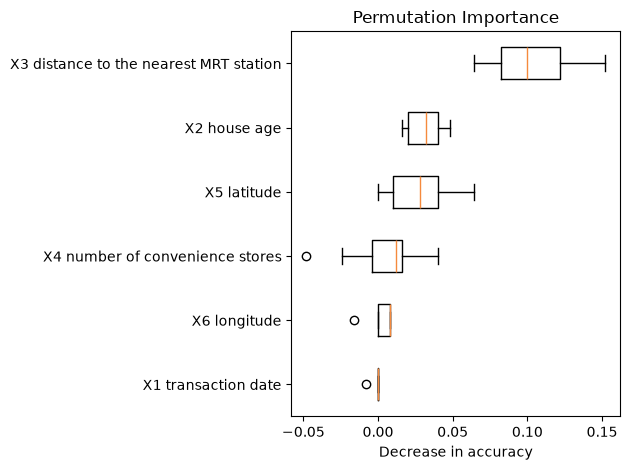

In [26]:
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(
    result.importances[sorted_idx].T,
    orientation="horizontal",
    tick_labels=X_test_scaled.columns[sorted_idx]
)

ax.set_title("Permutation Importance")
ax.set_xlabel("Decrease in accuracy")
fig.tight_layout()
plt.show()

The distance to the nearest MRT station is also the most important feature in the logistic model. House age and latitude have smaller importance, while the other features have little effect on accuracy.

<h2>6. Deployment</h2>

These models can help estimate real estate prices in New Taipei City. The linear model predicts the unit price. The logistic model predicts whether the price is above or below the mean price. New data must have the same features and be standardized with the same scaler. The dataset is small and covers only one area and time period, so the models should be retrained with newer local data before real use.